<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding Correlation**


Estimated time needed: **30** minutes


In this lab, you will work with a cleaned dataset to perform exploratory data analysis (EDA). You will examine the distribution of the data, identify outliers, and determine the correlation between different columns in the dataset.


## Objectives


In this lab, you will perform the following:


- Identify the distribution of compensation data in the dataset.

- Remove outliers to refine the dataset.

- Identify correlations between various features in the dataset.


## Hands on Lab


##### Step 1: Install and Import Required Libraries


In [1]:
# Install the necessary libraries
!pip install pandas
!pip install matplotlib
!pip install seaborn

# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 137.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 165.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 97.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 140.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 60.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 172.0 MB/s eta 0:00:00


### Step 2: Load the Dataset


In [2]:
# Load the dataset from the given URL
file_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"
df = pd.read_csv(file_url)

# Display the first few rows to understand the structure of the dataset
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


<h3>Step 3: Analyze and Visualize Compensation Distribution</h3>


**Task**: Plot the distribution and histogram for `ConvertedCompYearly` to examine the spread of yearly compensation among respondents.


<Axes: ylabel='Frequency'>

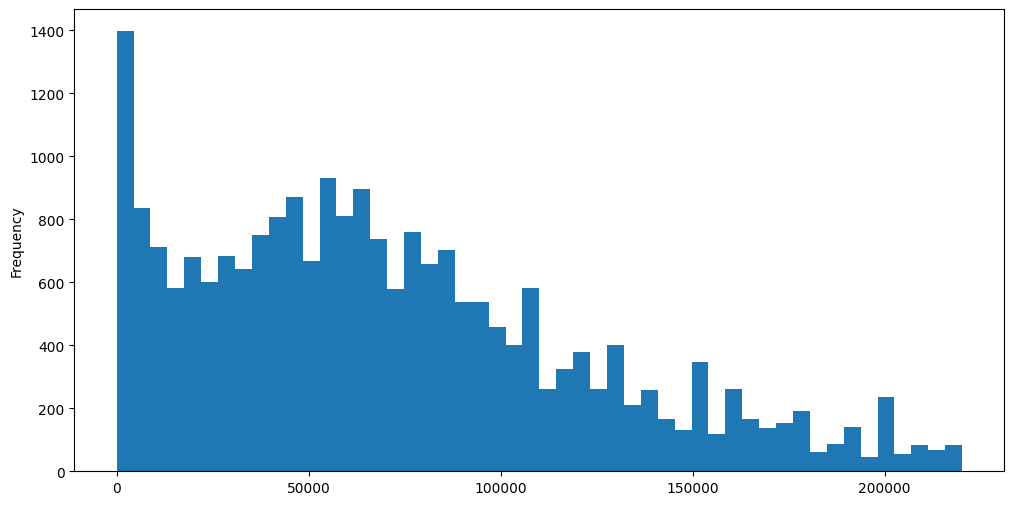

In [13]:
#remove outliers
q1_compy = df['ConvertedCompYearly'].describe()['25%']
q3_compy = df['ConvertedCompYearly'].describe()['75%']
iqr_compy = q3_compy - q1_compy
Lbound_compy = q1_compy - 1.5 * iqr_compy
Ubound_compy = q3_compy + 1.5 * iqr_compy
noiqr_compy = df[(df['ConvertedCompYearly'] >= Lbound_compy) & (df['ConvertedCompYearly'] <= Ubound_compy)]

#plot histogram
noiqr_compy['ConvertedCompYearly'].plot(kind = 'hist' , bins = 50 , figsize = (12 , 6))

<h3>Step 4: Calculate Median Compensation for Full-Time Employees</h3>


**Task**: Filter the data to calculate the median compensation for respondents whose employment status is "Employed, full-time."


In [15]:
## Write your code here
Full_Median = noiqr_compy.loc[noiqr_compy['Employment'] == 'Employed, full-time' , 'ConvertedCompYearly'].median()
Full_Median

np.float64(66769.0)

<h3>Step 5: Analyzing Compensation Range and Distribution by Country</h3>


Explore the range of compensation in the ConvertedCompYearly column by analyzing differences across countries. Use box plots to compare the compensation distributions for each country to identify variations and anomalies within each region, providing insights into global compensation trends.



/tmp/ipykernel_299/3662270433.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([us_compy, ger_compy, ukr_compy] , labels = ['USA' , 'Germany' , 'Ukraine'])


Text(0, 0.5, 'Yearly Compensation')

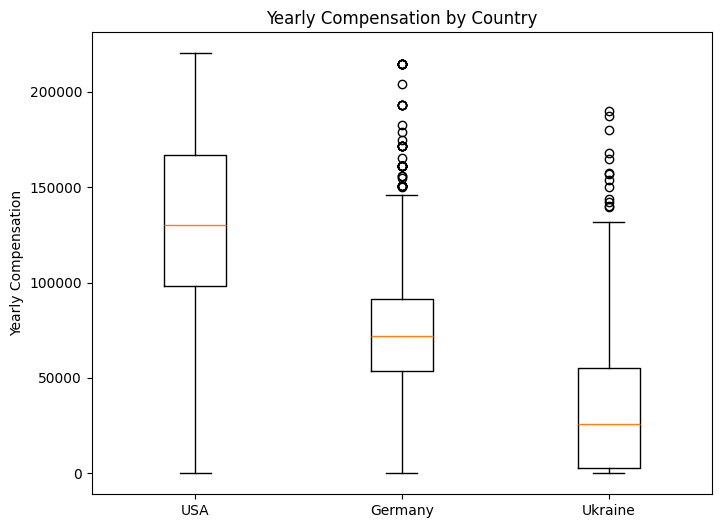

In [23]:
##create variables for a few countries
us_compy = noiqr_compy.loc[noiqr_compy['Country'] == 'United States of America' , 'ConvertedCompYearly']
ger_compy = noiqr_compy.loc[noiqr_compy['Country'] == 'Germany' , 'ConvertedCompYearly']
ukr_compy = noiqr_compy.loc[noiqr_compy['Country'] == 'Ukraine' , 'ConvertedCompYearly']

fig , ax = plt.subplots(figsize = (8 , 6))

ax.boxplot([us_compy, ger_compy, ukr_compy] , labels = ['USA' , 'Germany' , 'Ukraine'])
ax.set_title('Yearly Compensation by Country')
ax.set_ylabel('Yearly Compensation')

In [ ]:
#USA has the highest median compensation out of the 3 countries by far - which means workers in the us typically make more in this profession than in other countries.
#USA also has the largest IQR among the countries being compared, so there is also a larger gap in pay between employees as well. 
#It's overall pay is still the highest even with outliers removed.
#Germany has the most even distribution of pay among these countries.
#It has lower pay than the USA but higher than Ukraine.
#Ukraine has the most overlap observed between them, with its lower quartile range being close to its minimum outlier. It's also the lowest paying country of the 3
#All countries are still positively skewed with high income outliers even when steps are taken to remove the largest outliers.
#Overall there is quite a large difference not only between the salaries from different countries, but also within the countries themselves.

<h3>Step 6: Removing Outliers from the Dataset</h3>


**Task**: Create a new DataFrame by removing outliers from the `ConvertedCompYearly` column to get a refined dataset for correlation analysis.


In [24]:
## already did this to analyze the compensation column
q1_compy = df['ConvertedCompYearly'].describe()['25%']
q3_compy = df['ConvertedCompYearly'].describe()['75%']
iqr_compy = q3_compy - q1_compy
Lbound_compy = q1_compy - 1.5 * iqr_compy
Ubound_compy = q3_compy + 1.5 * iqr_compy
noiqr_compy = df[(df['ConvertedCompYearly'] >= Lbound_compy) & (df['ConvertedCompYearly'] <= Ubound_compy)]

<h3>Step 7: Finding Correlations Between Key Variables</h3>


**Task**: Calculate correlations between `ConvertedCompYearly`, `WorkExp`, and `JobSatPoints_1`. Visualize these correlations with a heatmap.


In [28]:
## calc
corr_comp_exp_points1 = noiqr_compy[['ConvertedCompYearly' , 'WorkExp' , 'JobSatPoints_1']].corr()
corr_comp_exp_points1

,ConvertedCompYearly,WorkExp,JobSatPoints_1
ConvertedCompYearly,1.000000,0.408438,-0.058170
WorkExp,0.408438,1.000000,-0.032388
JobSatPoints_1,-0.058170,-0.032388,1.000000


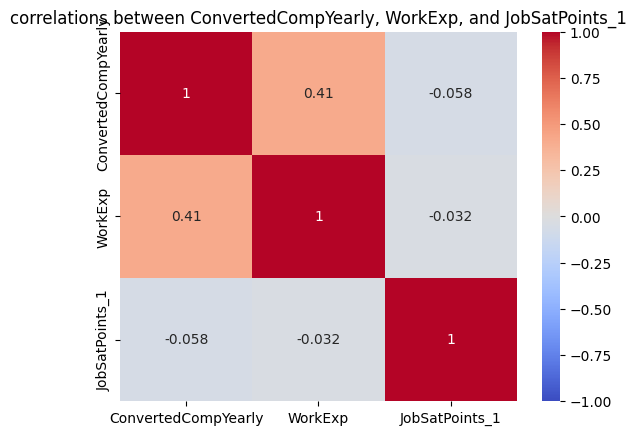

In [29]:
#heatmap
sns.heatmap(corr_comp_exp_points1 , annot = True , cmap = 'coolwarm' , vmin = -1 , vmax = 1)

plt.title('correlations between ConvertedCompYearly, WorkExp, and JobSatPoints_1')
plt.show()

<h3>Step 8: Scatter Plot for Correlations</h3>


**Task**: Create scatter plots to examine specific correlations between `ConvertedCompYearly` and `WorkExp`, as well as between `ConvertedCompYearly` and `JobSatPoints_1`.


In [39]:
#drop missing values
comp_exp = noiqr_compy[['ConvertedCompYearly', 'WorkExp']].dropna()
comp_jobsat1 = noiqr_compy[['ConvertedCompYearly', 'JobSatPoints_1']].dropna()

In [40]:
##calcs
print(comp_exp.corr())
print(comp_jobsat1.corr())

                     ConvertedCompYearly   WorkExp
ConvertedCompYearly             1.000000  0.408438
WorkExp                         0.408438  1.000000
                     ConvertedCompYearly  JobSatPoints_1
ConvertedCompYearly              1.00000        -0.05817
JobSatPoints_1                  -0.05817         1.00000


Text(0.5, 1.0, 'comp vs work exp')

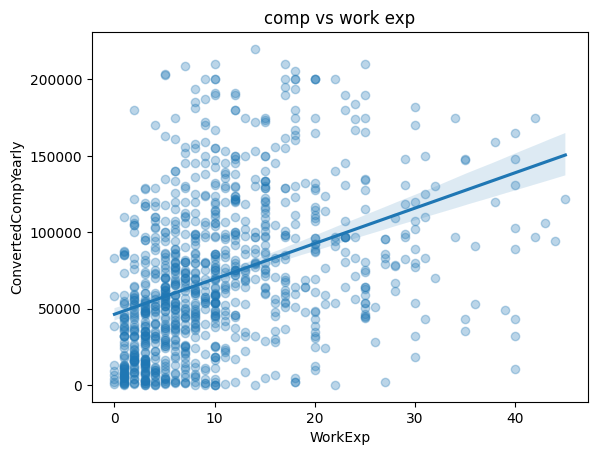

In [48]:
#plots - we are gonna use samples because the data set is huge
sample_comp_exp = comp_exp.sample(n = 1000 , random_state = 42)
sns.regplot(data = sample_comp_exp , x = 'WorkExp' , y = 'ConvertedCompYearly' , scatter_kws = {'alpha' : 0.3})
plt.title('comp vs work exp')

Text(0.5, 1.0, 'comp vs JobSatPoints_1')

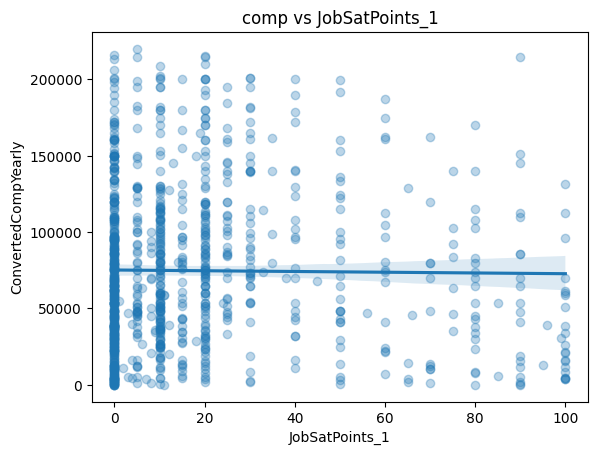

In [49]:
sample_comp_jobsat1 = comp_jobsat1.sample(n = 1000 , random_state = 42)
sns.regplot(data = sample_comp_jobsat1 , x = 'JobSatPoints_1' , y = 'ConvertedCompYearly' , scatter_kws = {'alpha' : 0.3})
plt.title('comp vs JobSatPoints_1')

<h3>Summary</h3>


In this lab, you practiced essential skills in correlation analysis by:

- Examining the distribution of yearly compensation with histograms and box plots.
- Detecting and removing outliers from compensation data.
- Calculating correlations between key variables such as compensation, work experience, and job satisfaction.
- Visualizing relationships with scatter plots and heatmaps to gain insights into the associations between these features.

By following these steps, you have developed a solid foundation for analyzing relationships within the dataset.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
